In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
pip install scikit-optimize

     |████████████████████████████████| 100 kB 3.6 MB/s 


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV, HalvingRandomSearchCV

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor

from scipy import stats
from skopt import BayesSearchCV
from skopt.space import Real, Categorical

In [ ]:
data = pd.read_csv('penguins_size.csv')

data = data.dropna()
data = data.drop(['sex', 'island', 'flipper_length_mm', 'body_mass_g'], axis=1)

In [ ]:
X = data.drop(['species'], axis=1)

ss = StandardScaler()
X = ss.fit_transform(X)

y = data['species']
spicies = {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}
y = [spicies[item] for item in y]
y = np.array(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33)

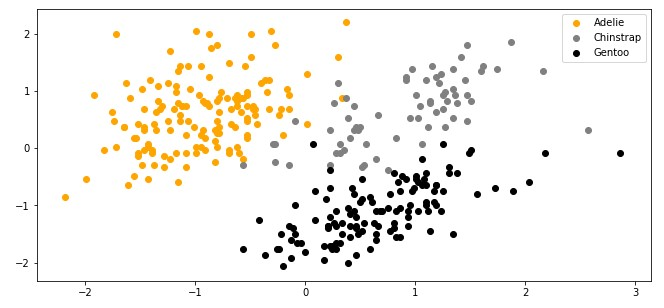

**Grid Search Hyperparameter**

In our example, we use SVM algorithm for classification. There are three hyperparameters that we take into consideration – C, gamma and kernel. To understand them in more detail, check out this article. For C we want to check the following values: 0.1, 1, 100, 1000; for gamma we use values: 0.0001, 0.001, 0.005, 0.1, 1, 3, 5, and for kernel we use values: ‘linear’ and ‘rbf’.

In [ ]:
hyperparameters = {
    'C': [0.1, 1, 100, 1000],
    'gamma': [0.0001, 0.001, 0.005, 0.1, 1, 3, 5],
    'kernel': ('linear', 'rbf')
}

We utilize Sci-Kit Learn and its SVC class which contains the implementation of SVM for classification. Apart from that, we use GridSearchCV class, which is used for grid search optimization. Combined that looks like this:

In [ ]:
grid = GridSearchCV(
        estimator=SVC(),
        param_grid=hyperparameters,
        cv=5,
	scoring='f1_micro',
	n_jobs=-1)

his class receives several parameters through the constructor:

estimator – the instance machine learning algorithm itself. We pass the new instance of the SVC class there.
param_grid – contains hyperparameter dictionary.
cv – Determines the cross-validation splitting strategy.
scoring – The validation metrics used to evaluate the predictions. We use F1 score.
n_jobs – Represents the number of jobs to run in parallel. Value -1 means that is using all processors.

In [ ]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 100, 1000],
                         'gamma': [0.0001, 0.001, 0.005, 0.1, 1, 3, 5],
                         'kernel': ('linear', 'rbf')},
             scoring='f1_micro')

In [ ]:
print(f'Best parameters: {grid.best_params_}')
print(f'Best score: {grid.best_score_}')

Best parameters: {'C': 1000, 'gamma': 0.1, 'kernel': 'rbf'}
Best score: 0.9626834381551361


In [ ]:
print(f'All results: {grid.cv_results_}')

All results: {'mean_fit_time': array([0.00219297, 0.00549612, 0.00192585, 0.00637074, 0.0027318 ,
       0.00647202, 0.00195742, 0.0086307 , 0.00191646, 0.0047298 ,
       0.00185437, 0.0066123 , 0.00198765, 0.00673714, 0.00175271,
       0.00796657, 0.00152035, 0.00631199, 0.00155721, 0.004601  ,
       0.00204515, 0.00390248, 0.00209374, 0.00256186, 0.00169444,
       0.01253419, 0.00166907, 0.00624323, 0.00410442, 0.00415368,
       0.00190334, 0.00253568, 0.00194159, 0.00197978, 0.00361023,
       0.00204306, 0.00249267, 0.0023787 , 0.00193491, 0.00357919,
       0.00190873, 0.00445209, 0.00384665, 0.00231838, 0.00391612,
       0.00183792, 0.00412078, 0.00197101, 0.0037724 , 0.00261459,
       0.00397301, 0.0039062 , 0.00486598, 0.00386667, 0.00413747,
       0.00487757]), 'std_fit_time': array([3.14388036e-04, 3.25413591e-04, 7.86282063e-05, 1.27517799e-03,
       1.59435063e-03, 1.76119564e-03, 1.68958687e-04, 5.65094082e-03,
       7.32915000e-05, 1.84420844e-03, 9.36777393e-05

Ok, let’s now build this model and check how well it performs on the test dataset:

In [ ]:
model = SVC(C=500, gamma = 0.1, kernel = 'rbf')
model.fit(X_train, y_train)

preditions = model.predict(X_test)
print(f1_score(preditions, y_test, average='micro'))

0.9701492537313433


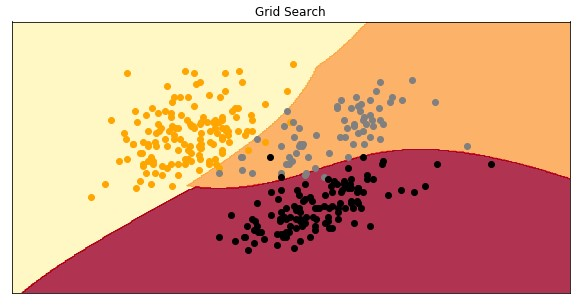

**Random Search Hyperparameter **

In [ ]:
hyperparameters = {
    "C": stats.uniform(500, 1500),
    "gamma": stats.uniform(0, 1),
    'kernel': ('linear', 'rbf')
}

random = RandomizedSearchCV(
                estimator = SVC(),
                param_distributions = hyperparameters,
                n_iter = 100,
                cv = 3,
                random_state=42,
                n_jobs = -1)

random.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=SVC(), n_iter=100, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_frozen object at 0x7f000b9274d0>,
                                        'gamma': <scipy.stats._distn_infrastructure.rv_frozen object at 0x7f000b927210>,
                                        'kernel': ('linear', 'rbf')},
                   random_state=42)

In [ ]:
print(f'Best parameters: {random.best_params_}')
print(f'Best score: {random.best_score_}')

Best parameters: {'C': 510.5994578295761, 'gamma': 0.023062425041415757, 'kernel': 'linear'}
Best score: 0.9700374531835205


In [ ]:
print(f'All results: {random.cv_results_}')

All results: {'mean_fit_time': array([0.0044624 , 0.00630959, 0.00204166, 0.01231591, 0.00391738,
       0.00186825, 0.00970213, 0.00289385, 0.00270073, 0.00267108,
       0.00732247, 0.005464  , 0.00892886, 0.0019931 , 0.00985249,
       0.00226593, 0.00271177, 0.00452884, 0.00472148, 0.00564408,
       0.00515175, 0.00423582, 0.01851734, 0.01443744, 0.01960643,
       0.00395306, 0.00817267, 0.00297515, 0.00215038, 0.01047126,
       0.02189445, 0.00931557, 0.00652488, 0.00627915, 0.00726755,
       0.01502562, 0.01182453, 0.00674431, 0.01652074, 0.01304905,
       0.01110117, 0.02314369, 0.00702612, 0.0181601 , 0.00973678,
       0.00750621, 0.0040559 , 0.01119733, 0.02529279, 0.01685691,
       0.0075322 , 0.00320315, 0.00391738, 0.00702739, 0.00485746,
       0.00205215, 0.00271638, 0.00275699, 0.00863155, 0.0041612 ,
       0.00486811, 0.006634  , 0.00408888, 0.00498335, 0.00386294,
       0.00441519, 0.00798464, 0.0046796 , 0.00616447, 0.00491651,
       0.00453273, 0.0126977 , 

et’s do the same thing as we did fro Grid Search: create the model with proposed hyperparameters, check the score on the test dataset and plot out the model.

In [ ]:
model = SVC(C=510.5994578295761, gamma = 0.023062425041415757, kernel = 'linear')
model.fit(X_train, y_train)

preditions = model.predict(X_test)
print(f1_score(preditions, y_test, average='micro'))

0.9701492537313433
